# Deep Learning

## What is Deep Learning?

Deep learning is a subfield of machine learning that uses neural networks with multiple layers to learn patterns and representations from data automatically.

- A **pattern** is a regularity or meaningful structure found in data that helps in prediction.
- A **representation** is internal encoded forms of data learned from those patterns.

NOTE:

- Artificial Intelligence $\supset$ Machine Learning $\supset$ Deep Learning $\supset$ Generative AI

**Machine Learning:**

- Learn parameters of a function

**Deep Learning:**

- Learn parameters of a very deep compositional function

## Why Deep Learning?

To understand why we need deep learning, we must understand the limitations of traditional machine learning.

- Manual feature engineering is required (requires domain expertise)
- Traditional ML struggles with images, audio, text, and very high-dimensional data.
- Adding more data does not improve much performance after a certain point.

To overcome these problems we come to a solution called **deep learning**.

## Differences between ML and DL?

|Point|Machine Learning|Deep Learning|
|---|---|---|
|Feature Engineering|Mostly manual|Mostly automatic|
|Data requirement|works with small/medium data|Usually needs large data|
|Compute requirement|Lower|Higher|
|Best for|Structured/tabular data|Images, text, audio, complex patterns|
|Representation|Learns shallow patterns|Learns hierarchial features|

## What Enabled Deep Learning?

The three factors are crucial for advancement in deep learning:

1. **Big Data:** Availability of massive labeled datasets.
2. **Computational Power:** Rise of GPUs( enabled parallel computing)
3. **Better Algorithms:** Architectural innovations such as CNNs, Transformers, etc.

## The MP Neuron (1943)

- Also known as `The McCulloch-Pitts Neuron`
- The first mathematical model of a neuron. It operates on a simple principle: if enough inputs are active the neuron "fires".

**How it works:**

- Takes multiple binary inputs $(x_i \in {0,1})$
- Calculates their sum
- The output is 1 if the sum is $\geq$ to fixed threshold $(\theta)$ 0 otherwise.

**Significance:**

Proved that networks of these simple units could compute any logical function (e.g., AND, OR).


In [5]:
# MccCulloch-Pitts Neuron

def mp_neuron(inputs, threshold):
    
    # step 1: calculate the sum 
    total = sum(inputs)

    # step 2: apply threshold
    return 1 if total >= threshold else 0

# Example usage
inputs = [1, 0, 1, 1, 0, 1, 0, 1]
threshold = 5
output = mp_neuron(inputs, threshold)
print(f"Inputs: {inputs}")
print(f"Threshold: {threshold}")
print(f"Output of the McCulloch-Pitts neuron: {output}")

Inputs: [1, 0, 1, 1, 0, 1, 0, 1]
Threshold: 5
Output of the McCulloch-Pitts neuron: 1


In [10]:
# Using mp_neuron to implement a simple AND gate
## For AND, both input must be 1 so threshold should be 2

inputs_list = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

print("AND Gate")

for x in inputs_list:
    output = mp_neuron(x, threshold=2)
    print(f"{x} -> {output}")

AND Gate
[0, 0] -> 0
[0, 1] -> 0
[1, 0] -> 0
[1, 1] -> 1


In [11]:
# using mp_neuron to implement a simple OR gate
## For OR, at least one input must be 1 so threshold should be 1

print("OR Gate")

for x in inputs_list:
    output = mp_neuron(x, threshold=1)
    print(f"{x} -> {output}")

OR Gate
[0, 0] -> 0
[0, 1] -> 1
[1, 0] -> 1
[1, 1] -> 1


### Limitations of the MP Neuron

**1. No Feature Importance**

- All inputs are treated equally.
- Cannot learn which input is more important
- No **weights**

**2. No Learning**

- Threshold is fixed manually
- Cannot learn from data
- No training rule

**3. Only Binary I/O**

- Input & Output must be 0 or 1
- Cannot handle real world data

## The Perceptron (1958)

- A Perceptron is the simplest form of an artificial neural network neuron.
- It was proposed by `Frank Rosenblatt` in 1958.
- It is a binary classification algorithm
- It is an improved version of the MP neuron because it introduces:
  - weights
  - learning rule

**How it works?**

- Takes Input
- Multiplies them by weight
- Adds them together
- Adds a bias term
- Applies an activation rule
- Produces output

**Formula:** 

$$
y =
\begin{cases}
1, & \text{if } \sum w_i x_i + b \geq 0 \\
0, & \text{otherwise}
\end{cases}
$$

where,

- $x_i=$ inputs
- $w_i=$ weights
- $b=$ bias
- $y=$ output

### Role of weights in Perceptron

- Weights tell the neuron which features are more important.
- Generally, weights are initialized randomly then they are altered until the algorithm learns optimal weights.

### Role of Learning Rule in Perceptron

- The perceptron learns by updating weights.
- Basic idea:
  - correct prediction $\to$ keep weights
  - wrong prediction $\to$ adjust weights
- Learning rule: $$w_{new} = w_{old} + \eta (y_{true} - y_{pred})x$$ where 
  - $\eta=$ learning rate
  - $y_{true}=$ actual answer
  - $y_{pred}=$ predicted answer

### Strengths of Perceptron

- An automatic learning rule adjusts weights from data.
- Learns which inputs are more important via weights.
- If data is linearly separable, it's guaranteed to find a solution.

### Significance of Perceptron

- Unlike MP neurons, perceptrons can learn from data.
- Modern neural networks are built from perceptron-like neurons.
- No manual rule writing required.
- Can separate data using a line/hyperplane.




In [7]:
# =========================================================
# PERCEPTRON IMPLEMENTATION FROM SCRATCH USING NUMPY
# =========================================================
#
# Goal:
# Demonstrate how a perceptron learns a linearly
# separable binary classification problem.
#
# Libraries Used:
# - NumPy only
#
# What This Example Covers:
# - Synthetic dataset generation
# - Linearly separable data
# - Perceptron mathematics
# - Step activation function
# - Weight updates
# - Prediction
# - Accuracy calculation
#
# =========================================================

import numpy as np

# =========================================================
# 1. CREATE SYNTHETIC LINEARLY SEPARABLE DATA
# =========================================================
#
# We create two classes:
#
# Class 0:
# points near bottom-left
#
# Class 1:
# points near top-right
#
# These classes can be separated using a line.
# =========================================================

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],

    [6, 6],
    [6, 7],
    [7, 6],
    [7, 7]
])

y = np.array([
    0,
    0,
    0,
    0,

    1,
    1,
    1,
    1
])


# =========================================================
# 2. INITIALIZE WEIGHTS AND BIAS
# =========================================================
#
# weights:
# importance of each feature
#
# bias:
# shifts decision boundary
# =========================================================

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10

# =========================================================
# 3. STEP ACTIVATION FUNCTION
# =========================================================
#
# Perceptron uses a hard threshold:
#
# if z >= 0 -> output = 1
# else      -> output = 0
#
# =========================================================

def activation(z):

    if z >= 0:
        return 1
    else:
        return 0


# =========================================================
# 4. TRAINING LOOP
# =========================================================
#
# For every sample:
#
# Step 1:
# Compute weighted sum
#
# z = w.x + b
#
# Step 2:
# Apply activation function
#
# Step 3:
# Compute error
#
# error = y_true - y_pred
#
# Step 4:
# Update weights
#
# w = w + learning_rate * error * x
#
# Step 5:
# Update bias
#
# b = b + learning_rate * error
#
# =========================================================

print("\n================ TRAINING ================\n")

for epoch in range(epochs):

    total_error = 0

    for i in range(len(X)):

        # Current input sample
        x = X[i]

        # True label
        y_true = y[i]

        # -------------------------------------------------
        # FORWARD PASS
        # -------------------------------------------------

        # Weighted sum
        z = np.dot(weights, x) + bias

        # Prediction
        y_pred = activation(z)

        # -------------------------------------------------
        # ERROR CALCULATION
        # -------------------------------------------------

        error = y_true - y_pred

        total_error += abs(error)

        # -------------------------------------------------
        # WEIGHT UPDATE RULE
        # -------------------------------------------------

        weights = (
            weights
            + learning_rate * error * x
        )

        # Bias update
        bias = (
            bias
            + learning_rate * error
        )

    # Print training progress
    if epoch % 2 == 0:
        print(
        f"Epoch {epoch+1:02d} | "
        f"Error: {total_error} | "
        f"Weights: {weights} | "
        f"Bias: {bias:.2f}"
    )


# =========================================================
# 5. TESTING THE TRAINED PERCEPTRON
# =========================================================

print("\n================ TESTING ================\n")

correct_predictions = 0

for i in range(len(X)):

    x = X[i]

    y_true = y[i]

    # Weighted sum
    z = np.dot(weights, x) + bias

    # Prediction
    y_pred = activation(z)

    # Count correct predictions
    if y_pred == y_true:
        correct_predictions += 1

    print(
        f"Input: {x} | "
        f"Predicted: {y_pred} | "
        f"Actual: {y_true}"
    )


# =========================================================
# 6. ACCURACY
# =========================================================

accuracy = (
    correct_predictions / len(X)
) * 100

print(f"\nAccuracy: {accuracy:.2f}%")


# =========================================================
# 7. FINAL LEARNED PARAMETERS
# =========================================================

print("\n================ FINAL PARAMETERS ================\n")

print("Learned Weights:", weights)
print("Learned Bias:", bias)


# =========================================================
# 8. TRY NEW UNSEEN DATA
# =========================================================
#
# The perceptron should generalize to new points.
# =========================================================

new_points = np.array([
    [1, 3],
    [6, 5],
    [2, 2],
    [8, 8]
])

print("\n================ NEW PREDICTIONS ================\n")

for point in new_points:

    z = np.dot(weights, point) + bias

    prediction = activation(z)

    print(
        f"Point: {point} -> "
        f"Predicted Class: {prediction}"
    )


================ TRAINING ================

Epoch 01 | Error: 2 | Weights: [0.5 0.5] | Bias: 0.00
Epoch 03 | Error: 3 | Weights: [0.1 0.1] | Bias: -0.60
Epoch 05 | Error: 0 | Weights: [0.1 0.1] | Bias: -0.60
Epoch 07 | Error: 0 | Weights: [0.1 0.1] | Bias: -0.60
Epoch 09 | Error: 0 | Weights: [0.1 0.1] | Bias: -0.60

================ TESTING ================

Input: [1 1] | Predicted: 0 | Actual: 0
Input: [1 2] | Predicted: 0 | Actual: 0
Input: [2 1] | Predicted: 0 | Actual: 0
Input: [2 2] | Predicted: 0 | Actual: 0
Input: [6 6] | Predicted: 1 | Actual: 1
Input: [6 7] | Predicted: 1 | Actual: 1
Input: [7 6] | Predicted: 1 | Actual: 1
Input: [7 7] | Predicted: 1 | Actual: 1

Accuracy: 100.00%

================ FINAL PARAMETERS ================

Learned Weights: [0.1 0.1]
Learned Bias: -0.6

================ NEW PREDICTIONS ================

Point: [1 3] -> Predicted Class: 0
Point: [6 5] -> Predicted Class: 1
Point: [2 2] -> Predicted Class: 0
Point: [8 8] -> Predicted Class: 1


### Limitations of Perceptron

- Only problems where a single straight line (or hyperplane) can separate the classes can be solved.
- The step function activation is not differentiable, preventing modern gradient-based training.

## The Modern Neuron

- It is an improved version of the Perceptron.
- Unlike the classical perceptron, a modern neuron uses:
   - learnable weights
   - bias
   - differentiable activation functions
   - gradient-based learning

### How Modern Neuron works?

**Step 1: Linear Combination**

- Calculates a weighted sum of inputs plus a bias
- Output is $z = w \cdot x + b$

**Step 2: Non-Linear Activation**

- Passes the linear output z through an differentiable activation function $a = g(z)$

Note:

- Differentiability is the superpower.
- Why?  Differentiable $\to$ **gradient**. This gradient is used to adjust weights to fix errors. It is the core requirement for **backpropagation**.

# Deep Learning Tricks

## The Numerization Trick

Computers fundamentally operate on numerical computations.

Neural networks cannot directly process:

- text
- images
- categories
- audio

Everything must eventually become tensors/numbers.

### Encoding Categories

**Method 1: One-Hot Encoding**

- Represents a class as a binary vector
- One position is "hot" (1), all others are 0.
- Simple but inefficient for many classes

**Method 2: Embedding layers**

- Learns a dense, meaningful vector for each class
- Similar concepts get similar vectors
- Efficient & captures semantic relationships

## Learn the Function Trick

**Data and Functions**

- We frame problems as data (inputs & outputs).
- We frame solutions as a **function** that maps inputs to outputs.
- The ”learning task” is to find this function.

**Each Function has two parts**

- **The Form (Architecture)**
  - The function's template or structure.
  - Learning a structured function is more tractable than learning a arbitrary function.
- **The Parameters (w)**
  - The "dials" that tune the function.
  - Learned automatically from data.

> ChatGPT can be seen as one, massive function taking your prompt as input.

**Goal of Machine Learning**

Machine learning tries to approximate an unknown function hidden in data.

Example: $$f(x) = y$$ where,

- $x=$ input
- $y=$ output
- $f=$ learned mapping

## The Parameterization Trick

We define our model as a function with a set of learnable parameters (weights and biases), denoted by $\theta$. The goal of training is to find the optimal values for $\theta$

### The Model as a Function

We express the model's prediction as $$\hat{y} = f(x;\theta)$$

## From Learning to Optimization

Parameterization turns ”learning” into a clear problem: optimization.

**Step 1: Measuring Error**

- A **Loss Function** scores how "bad" our model is for a given set of parameters $\theta$. $$L(y, \hat{y}) = L(y, f(x;\theta)) \sim L(\theta)$$

**Step 2: The Goal**

- Our goal is to find the parameters $\theta^*$ that result in the lowest possible loss.

# Feedforward Network Architecture

## Network Topology: Building a Feedforward Network

**1. The Input Layer**

- Receives the data and just pass values along

**2. The Hidden Layers**

- The network's computational engine
- They learn increasingly abstract features.

**3. The Output Layer**

- Produces the final result (e.g., a prediction)

Important points

- **Feedforward Flow:** Information moves in one direction only: input $\to$ output. No loops.
- **Fully Connected:** Every neuron connects to every neuron in the next layer

## The Standard Forward Model: A Neuron's Calculation

**Step 1: The Linear Part (weighted sum)**

- A weighted sum of all inputs is calculated
- A bias term is added to this sum
- **Result:** $z = \sum_iw_ix_i + b$

**Step 2: The Non-Linear Part (Activation)**

- The result z is passed through a non-linear activation function g.
- This introduces complexity and allows the network to learn non-linear patterns.
- **Final Output:** $a = g(z)$

**The Fundamental Building Block**

This two-step "Linear Sum $\to$ Non-Linear Activation" process if performed by every single neuron in a deep neural network.


## Linear Model vs Artificial Neural Networks

**Linear Model**

A Linear Model is weighted sum of input features.

$$\hat{y} = \sum w_ix_i + b$$

**Neural Network Model**

A Neuron has a linear and a non-linear operation

$$z = \sum w_ix_i + b$$

$$a = g(z)$$

## The Forward Pass: The Vectorized Layer View

- **Problem:** Calculating neuron by neuron is incredibly inefficient.
- **Solution:** Compute an entire layer at once using **vectorized** operations (i.e., matrix multiplication)

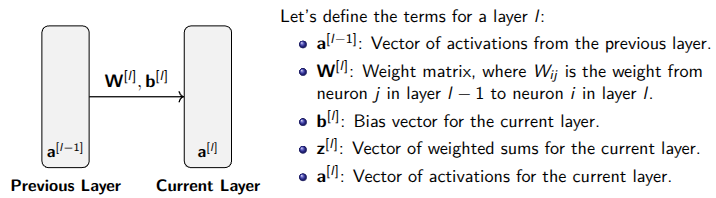

**The Two Core Equations (Vectorized)**

1. **Weighted Sum:** $z^{[l]} = W^{[l]}a^{[l-1]} + b^{[l]}$
2. **Activation:** $a^{[l]} = g(z^{[l]})$

**This is computationally efficient and perfectly suited for GPUs.**

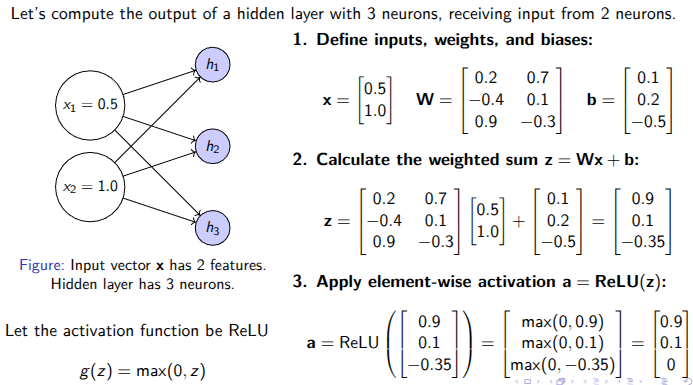

## The Multilayer Perceptron (MLP): Overcoming Limitations

**What is an MLP?**

Simply a feedforward network with **one or more hidden layers**.

**The Power of the Hidden Layer**

- A single Perceptron fails on non-linear data (like XOR)
- The hidden layer acts as an *automatic feature engineer*.
- It learns to **transform the data** into a new representation.
- In this new space, the data becomes *linearly separable*.
- This allows the MLP to create complex decision boundaries.

# Activation Functions: Introducing Non-Linearity

## Why do we need Activation Functions?

**The Problem: Stacking Linear Layers is Useless**

Without a non-linear activation function, a deep network simply collapses into a single linear model, no matter how many layers it has.

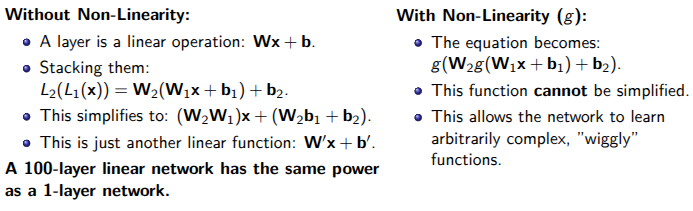

## Sigmoid

**Formula**

$$\sigma(z) = \frac{1}{1+e^-z}$$

**Properties**

- Squeezes any real number into the range (0, 1).
- Historically popular for its interpretation as a neuron’s ”firing rate.”
- Useful in output layers for binary classification (predicting probabilities).

**Problems**

- **Vanishing Gradients:** The function is flat at both ends. The gradient is near zero for large positive or negative inputs, which effectively stops learning in deep networks.
- **Not Zero-Centered:** Outputs are always positive, which can slow down learning.

## Tanh

**Formula**

$$tanh(z) = \frac{e^z-e^-z}{e^z+e^-z}$$

**Properties**

- Squeezes any real number into the range (−1, 1).
- **Zero-Centered:** Its major advantage over Sigmoid. This property helps center the data for the next layer, often speeding up convergence.

**Problems**

- **Vanishing Gradients:** Like Sigmoid, the function flattens out, and its gradients disappear for large positive or negative inputs, making it difficult to use in very deep networks.


## ReLU


**Formula**

$$ReLU(z) = \max(0,z)$$

**Properties**

- **Computationally Efficient**: Very fast to compute (just a threshold).
- **No Vanishing Gradient (for z > 0)**: The gradient is a constant 1 for positive inputs, allowing learning signals to propagate deep into the network.
- **Sparsity**: By outputting 0 for negative inputs, it can make the network sparse.

**Problems**

- **The ”Dying ReLU” Problem:** If a neuron’s weights are updated such that its pre-activation z is always negative, it will always output 0. The gradient will also be 0, and the neuron can never recover. It effectively ”dies.”


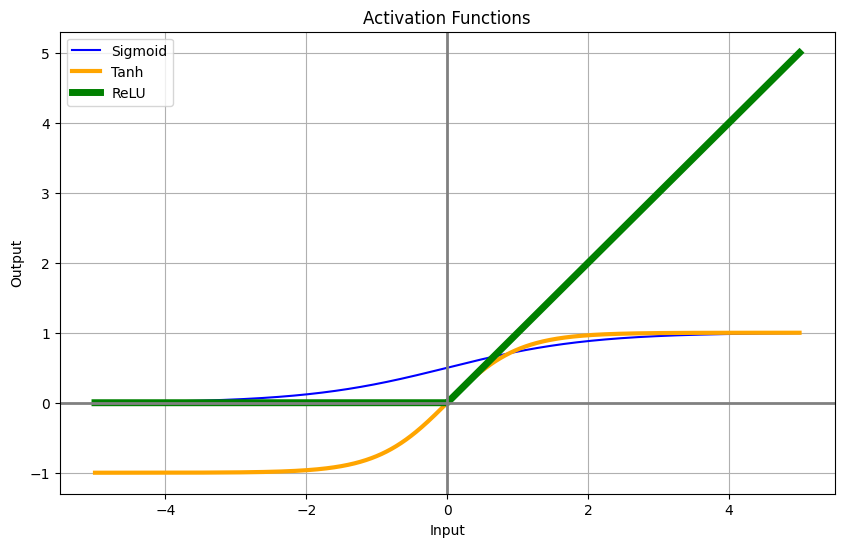

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5,5,1000)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label='Sigmoid', color='blue')
plt.plot(x, tanh, label='Tanh', color='orange', lw=3)
plt.plot(x, relu, label='ReLU', color='green', lw=5)
plt.title('Activation Functions')
plt.xlabel('Input')
plt.ylabel('Output')

plt.axhline(0, color='gray', lw=2)
plt.axvline(0, color='gray', lw=2)
plt.grid()
plt.legend()
plt.show()

## The ReLU Family: Fixing the ”Dying” Problem

### Leaky ReLU

$$f(z) = \begin{cases} z, & \text{ if } z > 0 \\ \alpha z, & \text{ if } z \leq 0 \end{cases}$$

(where $\alpha$ is a small constant like 0.01)

- **The Fix:** Introduces a small, non-zero gradient for negative inputs.
- This allows "dead" neurons to be revived. A very common and effective choice.

### GeLU (Gaussian Error Linear Unit)

- A smoother, probabilistic alternative to ReLU
- Became the standard in state-of-the-art **Transformer** models (e.g., GPT, BERT)

## A Practical Guide to Choosing Activations

**For Hidden Layers**

1. **Start with ReLU**. Most common, fastest, and usually works.
2. For issues with "dying" neurons, switch to **Leaky ReLU** or **Parametric ReLU**.
3. For Transformer-based models, consider **GELU** or **Swish**.

**For the Output Layer (Task-Dependent)**

1. **Binary Classification: Sigmoid.** Outputs a probability between 0 and 1.
2. **Multiclass Classification: Softmax.** Outputs a probability distribution over all classes (all outputs sum to 1)
3. **Regression: None(Linear).** The output can be any real number.

**Rule of Thumb**

- Never use sigmoid or tanh in hidden layers of modern deep networks due to the vanishing gradient problem. Their use is now almost exclusively in output layers.


# The Forward Pass and Measuring Error

## The Forward Pass: From Input to Prediction

The forward pass is the process of taking an input vector x and feeding it through the network,
layer by layer, to produce a final prediction $\hat{y}$

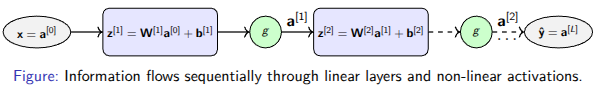

The computation for every layer follows the same two-step, vectorized pattern:

1. **Linear Combination:** Calculate the weighted sum for all neurons in the layer. $$z^{[l]} = W^{[l]}a^{[l-1]} + b^{[l]}$$
2. **Non-linear Activation:** Apply the activation function element-wise. $$a^{[l]} = g(z^{[l]})$$

The final activation vector $a^{[L]}$ is the network's prediction $\hat{y}$

## Loss Functions: Quantifying the Error

A loss function $L(y, \hat{y})$ takes the true label $(y)$ and the prediction $(\hat{y})$ and returns a single number representing the error. This error is what we aim to minimize during training.

### For Regression Tasks

**Mean Squared Error (MSE)** 

$$L_{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i-\hat{y_i})^2 $$

- Calculates the average squared difference between true and predicted values.
- Penalizes large errors very heavily

### For Classification Tasks

**Cross-Entropy Loss**

$$L_{CE} = - \sum_{c=1}^C y_c \log(\hat{y}_c)$$

- $y_c$ is 1 if c is the true class, 0 otherwise.
- $\hat{y}_c$ is the predicted probability for class c.
- Penalizes the model for being confident and wrong


# Gradient Descent

## Why Gradient Descent?

**The Goal**

Find the parameters $\theta$ that minimizes the loss function $L(y, f(x;\theta))$.

**The Update Rule**

At each step, we move in the direction of steepest descent: $$\theta_{new} = \theta_{old} - \eta \nabla L(y, f(x;\theta_{old}))$$

**The Challenge: Local vs Global Minima**

- **Global Minimum:** The true lowest point; the optimal solution.
- **Local Minimum:** A "valley" that traps the algorithm, preventing it from reaching the global minimum.

## GD in Action: Linear Regression

**1. The Model**

- Find the best line $\hat{y} = mx + c$. Parameters are $\theta = {m,c}$

**2. The Loss Function (MSE)**

$$L(m,c) = \frac{1}{N} \sum(y_i-\hat{y}_i)^2$$

**3. The Update Rules**

$$m := m - \eta \frac{\partial L}{\partial m}$$

$$c := c - \eta \frac{\partial L}{\partial c}$$

## GD: A Practical Comparison

|Aspect|Batch GD|Stochastic GD (SGD)|Mini-Batch GD|
|---|---|---|---|
|Data Usage|Entire Dataset|Single data point|mini-batch of data|
|Update Frequency|Once per epoch|after each data point|After each mini-batch|
|Convergence Speed|Slow|Fast (per iteration)|Moderate|
|Convergence Stability|Smooth and stable|Noisy and erratic|Relatively smooth|
|Computational Efficiency|Inefficient for large data|Efficient|Very Efficient (GPUs)|
|Memory Requirement|High|Low|Moderate|

**The Winner: Mini-Batch Gradient Descent**
For nearly all modern deep learning applications, **Mini-Batch GD** is the standard. It offers the best compromise between stability of Batch GD and the speed of SGD, while being perfectly suited for parallelization on GPUs.

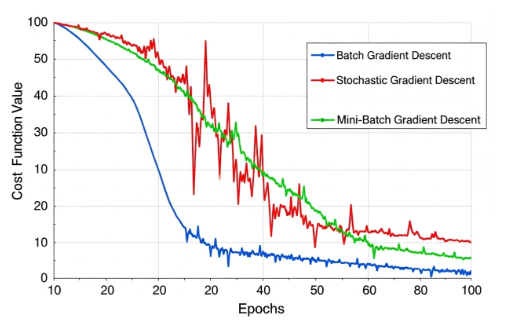

# Backpropagation

**The Question**

How does a small change in an early parameter $(w_1)$ affect the final loss $(L)$ at the end of a long chain of computations?

The chain Rule provides the answer by multiplying local derivatives.

Imagine a function $L(y(x))$. We want to find how L changes with respect to x, which is $\frac{dL}{dx}$. 

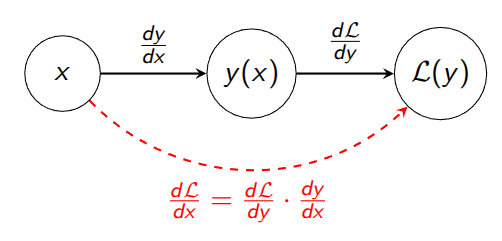

## Scalar Case: A Simple Chain

- we know how L changes with respect to y $(\frac{dL}{dy})$
- we know how y changes with respect to x $(frac{dy}{dx})$

The chain rule lets us link them: $$\frac{dL}{dx} = \frac{dl}{dy} \cdot \frac{dy}{dx}$$

## Vector Case (Generalization)

For vector functions $y = f(x)$ and $L = g(y)$, the derivates become Jacobian Matrices, and the chain rule becomes matrix multiplication: $$\nabla _xL = (J_YL)(J_Xy)$$

This is the mathematical foundation for backpropagation in neural networks.

## Visualizing Computations: The Computational Graph

Any Mathematical expression can be decomposed into a graph of basic operations. This makes the flow of derivatives explicit.

**Example Expression: $L=(a+b) \cdot c$**

- We can break this down into intermediate steps: $d = a + b$ and $L = d \cdot c$.

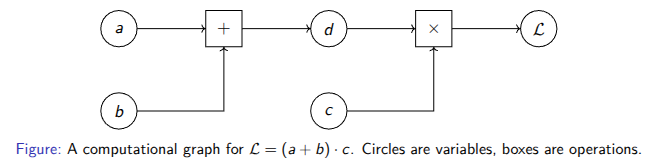

**Two passes of Automatic Differentiation**

- **Forward Pass:** We start with input values (a,b,c) and compute the values of all nodes, flowing from left to right, until we get the final output L.
- **Backward Pass (Backpropagation):** We start from the end with the gradient $\frac{dL}{dL} = 1$. We then go backwards (right to left), using the chain rule at each node to compute the gradient of L with respect to every input of that node.

# The XOR Problem